<a href="https://colab.research.google.com/github/Clinton1029/Heart_prediction1/blob/main/Heart_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Heart Disease Prediction Using Machine Learning

## Project Overview

Heart disease is one of the leading causes of death worldwide. Early prediction of heart disease can help healthcare professionals provide timely treatment and improve patient outcomes. This project aims to develop a machine learning model capable of predicting whether a patient has heart disease based on various health indicators and lifestyle factors.

The dataset contains demographic information, medical history, lifestyle habits, and health conditions such as BMI, smoking status, alcohol consumption, physical activity, diabetes, and other risk factors.

The project follows the standard machine learning workflow from data loading to model deployment.

# Project Workflow

The project follows these major steps:

1. Import Required Libraries
2. Load the Dataset
3. Exploratory Data Analysis (EDA)
4. Data Preprocessing and Preparation
5. Feature Selection
6. Split the Dataset into Training and Testing Sets
7. Choose the Machine Learning Model
8. Train the Machine Learning Model
9. Make Predictions
10. Evaluate Model Performance
11. Hyperparameter Tuning
12. Predict Heart Disease for New Patients

# 1. Import Libraries

In [46]:

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder



# 2. Load the Data

In [6]:
# Define the path to your file
file_path = "/content/Heart Disease.xlsx"

# Check if the file exists
if os.path.exists(file_path):
    print("File exists! Loading with pandas...")

    # Load the CSV file
    df = pd.read_excel(file_path)

    print("\nDataset loaded successfully!")

else:
    print("FILE DOESN'T EXIST")

File exists! Loading with pandas...

Dataset loaded successfully!


# 3. Exploratory Data Analysis

### 3.1 Display the First Five Records


In [7]:
df.head()

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3,30,No,Female,55-59,White,Yes,Yes,Very good,5,Yes,No,Yes
1,No,20.34,No,No,Yes,0,0,No,Female,80 or older,White,No,Yes,Very good,7,No,No,No
2,No,26.58,Yes,No,No,20,30,No,Male,65-69,White,Yes,Yes,Fair,8,Yes,No,No
3,No,24.21,No,No,No,0,0,No,Female,75-79,White,No,No,Good,6,No,No,Yes
4,No,23.71,No,No,No,28,0,Yes,Female,40-44,White,No,Yes,Very good,8,No,No,No


### 3.2 Display the Last Five Records


In [8]:
df.tail()

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
319790,Yes,27.41,Yes,No,No,7,0,Yes,Male,60-64,Hispanic,Yes,No,Fair,6,Yes,No,No
319791,No,29.84,Yes,No,No,0,0,No,Male,35-39,Hispanic,No,Yes,Very good,5,Yes,No,No
319792,No,24.24,No,No,No,0,0,No,Female,45-49,Hispanic,No,Yes,Good,6,No,No,No
319793,No,32.81,No,No,No,0,0,No,Female,25-29,Hispanic,No,No,Good,12,No,No,No
319794,No,46.56,No,No,No,0,0,No,Female,80 or older,Hispanic,No,Yes,Good,8,No,No,No


### 3.3 Dataset Shape

The shape of the dataset provides the number of observations (rows) and features (columns). This helps us understand the size of the dataset before performing further analysis.

In [9]:
# Display the number of rows and columns
print("Dataset Shape:", df.shape)

Dataset Shape: (319795, 18)


### 3.4 Dataset Information

The dataset information provides a concise summary of the DataFrame, including the number of entries, column names, non-null values, and data types.

 It also helps identify missing values and understand the overall structure of the dataset.

In [10]:
# Display dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319795 entries, 0 to 319794
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   HeartDisease      319795 non-null  object 
 1   BMI               319795 non-null  float64
 2   Smoking           319795 non-null  object 
 3   AlcoholDrinking   319795 non-null  object 
 4   Stroke            319795 non-null  object 
 5   PhysicalHealth    319795 non-null  int64  
 6   MentalHealth      319795 non-null  int64  
 7   DiffWalking       319795 non-null  object 
 8   Sex               319795 non-null  object 
 9   AgeCategory       319795 non-null  object 
 10  Race              319795 non-null  object 
 11  Diabetic          319795 non-null  object 
 12  PhysicalActivity  319795 non-null  object 
 13  GenHealth         319795 non-null  object 
 14  SleepTime         319795 non-null  int64  
 15  Asthma            319795 non-null  object 
 16  KidneyDisease     31

### 3.5 Descriptive Statistics

Descriptive statistics summarize the numerical features of the dataset by providing measures such as count, mean, standard deviation, minimum, maximum, and quartiles. These statistics help us understand the distribution and variability of the data.

In [11]:
# Display descriptive statistics for numerical features
df.describe()

,BMI,PhysicalHealth,MentalHealth,SleepTime
count,319795.000000,319795.00000,319795.000000,319795.000000
mean,28.325399,3.37171,3.898366,7.097075
std,6.356100,7.95085,7.955235,1.436007
min,12.020000,0.00000,0.000000,1.000000
25%,24.030000,0.00000,0.000000,6.000000
50%,27.340000,0.00000,0.000000,7.000000
75%,31.420000,2.00000,3.000000,8.000000
max,94.850000,30.00000,30.000000,24.000000


In [12]:
# Display descriptive statistics for categorical features
df.describe(include='object')

,HeartDisease,Smoking,AlcoholDrinking,Stroke,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,Asthma,KidneyDisease,SkinCancer
count,319795,319795,319795,319795,319795,319795,319795,319795,319795,319795,319795,319795,319795,319795
unique,2,2,2,2,2,2,13,6,4,2,5,2,2,2
top,No,No,No,No,No,Female,65-69,White,No,Yes,Very good,No,No,No
freq,292422,187887,298018,307726,275385,167805,34151,245212,269653,247957,113858,276923,308016,289976


### 3.6 Data Types

Each feature in the dataset has a specific data type, such as integer, float, or object (categorical).

 Identifying data types is important for selecting appropriate preprocessing techniques before training machine learning models.

In [13]:
# Display the data type of each column
df.dtypes

,0
HeartDisease,object
BMI,float64
Smoking,object
AlcoholDrinking,object
Stroke,object
PhysicalHealth,int64
MentalHealth,int64
DiffWalking,object
Sex,object
AgeCategory,object


### 3.7 Distribution of the Target Variable

The target variable indicates whether a patient has heart disease.

Examining its distribution helps determine whether the dataset is balanced or imbalanced.

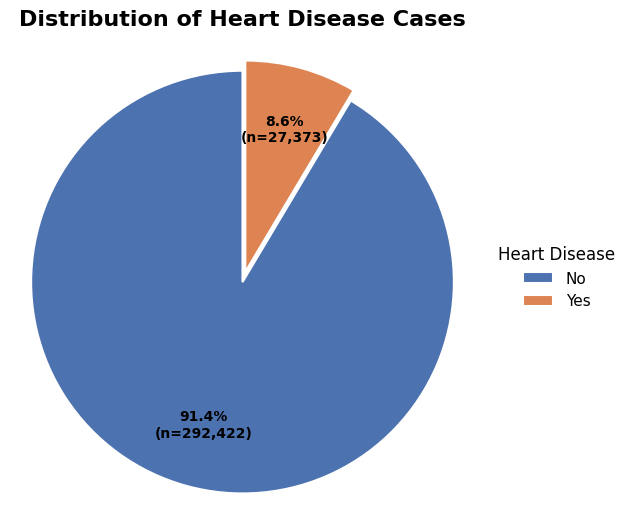

In [26]:
# Distribution of the Target Variable (Heart Disease)

heart_counts = df["HeartDisease"].value_counts()

# Function to display percentage and count
def autopct(pct):
    total = heart_counts.sum()
    count = int(round(pct * total / 100))
    return f'{pct:.1f}%\n(n={count:,})'

# Create figure
fig, ax = plt.subplots(figsize=(6, 6))

# Pie chart
wedges, texts, autotexts = ax.pie(
    heart_counts,
    autopct=autopct,
    startangle=90,
    colors=['#4C72B0', '#DD8452'],
    explode=(0, 0.05),                # Slightly highlight "Yes"
    pctdistance=0.7,
    wedgeprops={
        'edgecolor': 'white',
        'linewidth': 1.5
    },
    textprops={
        'fontsize': 11,
        'color': 'black'
    }
)

# Improve percentage text
for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_weight('bold')

# Title
ax.set_title(
    "Distribution of Heart Disease Cases",
    fontsize=16,
    fontweight='bold',
    pad=15
)

# Legend
ax.legend(
    wedges,
    ['No', 'Yes'],
    title="Heart Disease",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=11,
    title_fontsize=12,
    frameon=False
)

# Keep pie circular
ax.axis('equal')

plt.show()

### Interpretation

The pie chart shows that **91.4% (292,422)** of the individuals in the dataset do **not** have heart disease, while **8.6% (27,373)** have heart disease.

 This indicates that the dataset is **imbalanced**, with the majority of observations belonging to the "No" class.

Therefore, model evaluation should not rely solely on accuracy but also consider metrics such as precision, recall, and F1-score.

### 3.8  Heart Disease by Gender

This visualization compares the occurrence of heart disease between males and females.

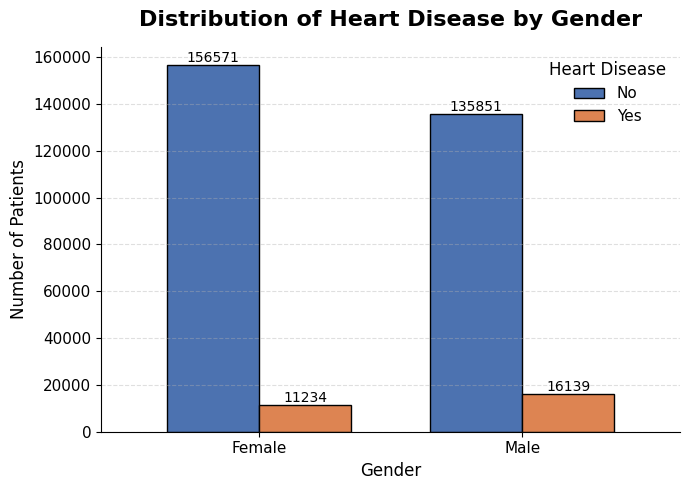

In [29]:
# Heart Disease by Gender

ax = pd.crosstab(
    df["Sex"],
    df["HeartDisease"]
).plot(
    kind="bar",
    figsize=(7, 5),
    color=["#4C72B0", "#DD8452"],
    edgecolor="black",
    width=0.7
)

# Title and labels
plt.title(
    "Distribution of Heart Disease by Gender",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Gender", fontsize=12)
plt.ylabel("Number of Patients", fontsize=12)

# Improve ticks
plt.xticks(rotation=0, fontsize=11)
plt.yticks(fontsize=11)

# Legend
plt.legend(
    title="Heart Disease",
    labels=["No", "Yes"],
    fontsize=11,
    title_fontsize=12,
    frameon=False
)

# Add count labels on bars
for container in ax.containers:
    ax.bar_label(container, fontsize=10)

# Gridlines
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Remove unnecessary borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

#### Interpretation

The bar chart compares the distribution of heart disease cases across gender.

 The dataset contains more **female** participants than **male** participants. However, the number of individuals with heart disease is higher among **males (16,139)** than **females (11,234)**.

 This suggests that, within this dataset, males appear to have a higher prevalence of heart disease than females, indicating that gender may be an important factor in predicting heart disease.

### 3.9 Heart Disease by Age Category

This chart illustrates how heart disease is distributed across different age groups.

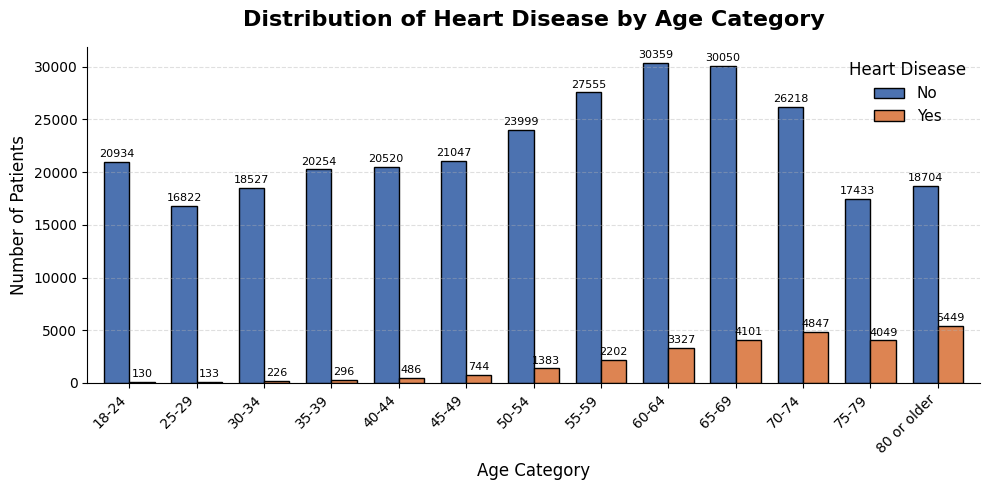

In [33]:
# Heart Disease by Age Category

ax = pd.crosstab(
    df["AgeCategory"],
    df["HeartDisease"]
).plot(
    kind="bar",
    figsize=(10, 5),
    color=["#4C72B0", "#DD8452"],
    edgecolor="black",
    width=0.75
)

# Title and labels
plt.title(
    "Distribution of Heart Disease by Age Category",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Age Category", fontsize=12)
plt.ylabel("Number of Patients", fontsize=12)

# Tick formatting
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

# Legend
plt.legend(
    title="Heart Disease",
    labels=["No", "Yes"],
    fontsize=11,
    title_fontsize=12,
    frameon=False
)

# Add count labels
for container in ax.containers:
    ax.bar_label(
        container,
        fontsize=8,
        padding=2
    )

# Add gridlines
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Remove top and right borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

#### Interpretation

The chart shows that the number of heart disease cases generally increases with age.

Younger age groups (18–49 years) have relatively few cases, while the prevalence rises substantially from the **50–54** age group onwards, with the highest number of cases observed among individuals aged **80 years or older**.

 This suggests that **age is an important risk factor** and is likely to be a strong predictor of heart disease.

### 4.0 Heart Disease by General Health

### Heart Disease by General Health

This grouped bar chart compares the number of individuals with and without heart disease across different self-reported general health categories.

It helps assess whether the prevalence of heart disease varies with an individual's overall health status.

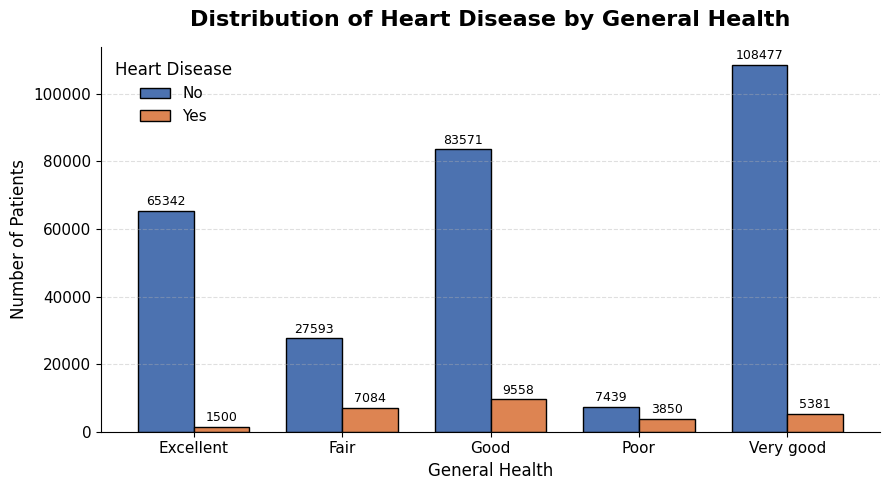

In [36]:
# Heart Disease by General Health

ax = pd.crosstab(
    df["GenHealth"],
    df["HeartDisease"]
).plot(
    kind="bar",
    figsize=(9, 5),
    color=["#4C72B0", "#DD8452"],
    edgecolor="black",
    width=0.75
)

# Title and labels
plt.title(
    "Distribution of Heart Disease by General Health",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("General Health", fontsize=12)
plt.ylabel("Number of Patients", fontsize=12)

# Tick formatting
plt.xticks(rotation=0, fontsize=11)
plt.yticks(fontsize=11)

# Legend
plt.legend(
    title="Heart Disease",
    labels=["No", "Yes"],
    fontsize=11,
    title_fontsize=12,
    frameon=False
)

# Add count labels
for container in ax.containers:
    ax.bar_label(
        container,
        fontsize=9,
        padding=2
    )

# Add horizontal gridlines
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Remove unnecessary borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

#### Interpretation

The chart shows that individuals who reported **Fair** or **Poor** general health have a relatively higher number of heart disease cases compared to those reporting **Excellent**, **Very good**, or **Good** health.

Although the **Very good** category contains the largest number of participants, only a small proportion have heart disease.

 This suggests that poorer self-reported general health is associated with a higher likelihood of heart disease, making **general health** an important predictor in the machine learning model.

### 4.1 Distribution of Numerical Features

Histograms are used to visualize the distribution of numerical variables.

 They help identify the shape of the data, including whether it is symmetric, skewed, or contains multiple peaks.

Machine learning models benefit from understanding relationships between variables.

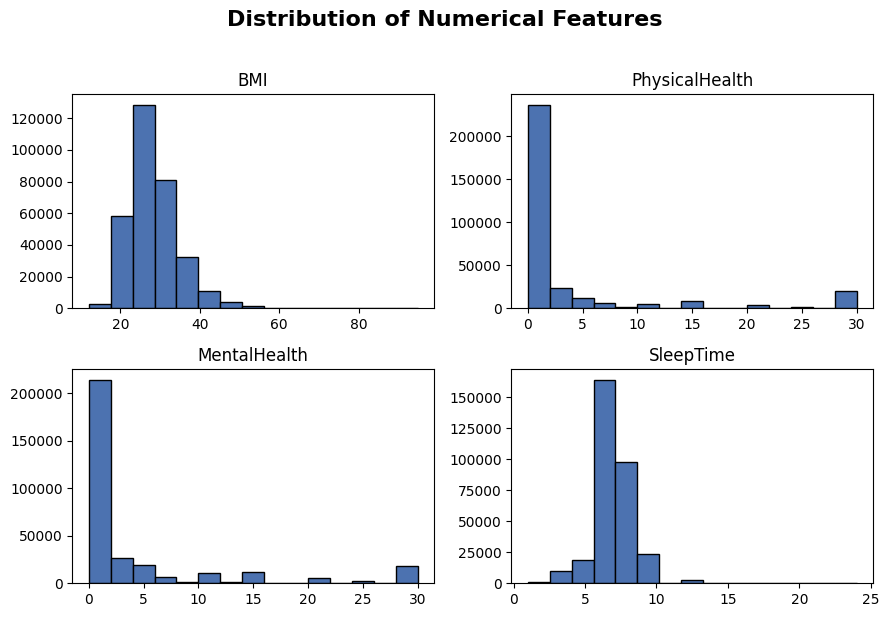

In [39]:
# Numerical features
numerical_features = ["BMI", "PhysicalHealth", "MentalHealth", "SleepTime"]

# Create histograms
df[numerical_features].hist(
    figsize=(9, 6),
    bins=15,
    color="#4C72B0",
    edgecolor="black",
    grid=False
)

# Overall title
plt.suptitle(
    "Distribution of Numerical Features",
    fontsize=16,
    fontweight="bold",
    y=1.02
)

# Adjust spacing
plt.tight_layout()

plt.show()

#### Interpretation

The histograms show that the numerical features have different distributions. **BMI** and **SleepTime** are approximately bell-shaped, with most observations concentrated around their central values.

In contrast, **PhysicalHealth** and **MentalHealth** are positively skewed, with many individuals reporting few unhealthy days and relatively fewer reporting a high number of unhealthy days.

These patterns indicate that some features may contain skewness, which should be considered during data preprocessing.

### 4.2 Boxplots of Numerical Features

Boxplots summarize the distribution of numerical variables by displaying the median, quartiles, and potential outliers.

They are useful for detecting extreme values and understanding the spread of the data.

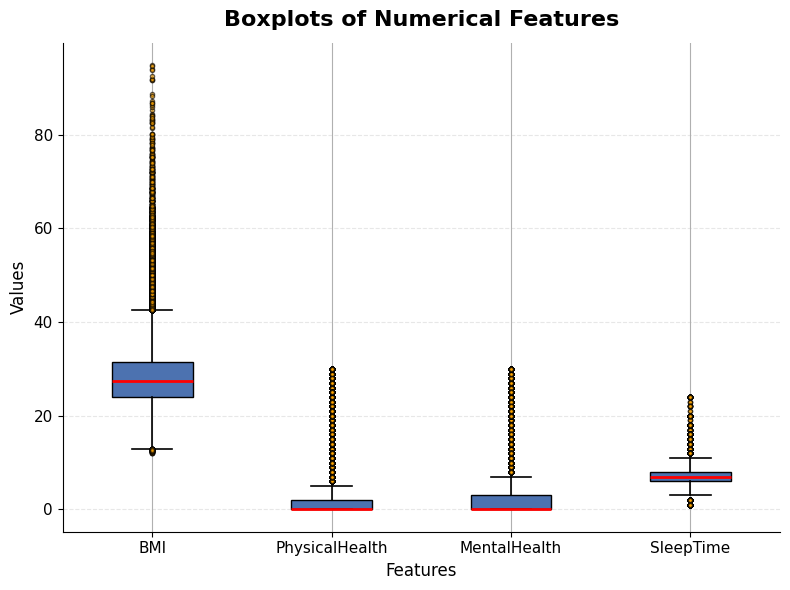

In [42]:
# Boxplots of Numerical Features

plt.figure(figsize=(8, 6))

df.boxplot(
    column=["BMI", "PhysicalHealth", "MentalHealth", "SleepTime"],
    patch_artist=True,
    boxprops=dict(facecolor="#4C72B0", edgecolor="black"),
    medianprops=dict(color="red", linewidth=2),
    whiskerprops=dict(color="black", linewidth=1.2),
    capprops=dict(color="black", linewidth=1.2),
    flierprops=dict(
        marker='o',
        markerfacecolor='orange',
        markeredgecolor='black',
        markersize=3,
        alpha=0.6
    )
)

plt.title(
    "Boxplots of Numerical Features",
    fontsize=16,
    fontweight="bold",
    pad=12
)

plt.xlabel("Features", fontsize=12)
plt.ylabel("Values", fontsize=12)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.3)

# Remove unnecessary borders
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

#### Interpretation

The boxplots indicate that all numerical features contain potential outliers, particularly **BMI**, which exhibits the greatest variability and the highest number of extreme values.

 **PhysicalHealth** and **MentalHealth** are concentrated at lower values with several high-value outliers, while **SleepTime** is more evenly distributed around its median with comparatively fewer outliers.

These observations suggest that the dataset contains extreme values that should be considered during preprocessing, although tree-based models such as Random Forest are generally robust to outliers.

## 4. Data Preprocessing and Preparation
 It involves transforming raw data into a clean and suitable format for model training.

 In this stage, the dataset is checked for missing values, duplicate records, and potential outliers.

  Categorical variables are encoded into numerical form, and the features are prepared for machine learning algorithms.

### 4.1 Check for Missing Values

Missing values can negatively affect the performance of machine learning models.

Therefore, the dataset is examined to ensure that all features contain complete observations.

In [43]:
# Check for missing values
df.isnull().sum()

,0
HeartDisease,0
BMI,0
Smoking,0
AlcoholDrinking,0
Stroke,0
PhysicalHealth,0
MentalHealth,0
DiffWalking,0
Sex,0
AgeCategory,0


##### No null values

### 4.2  Check for Duplicate Records

Duplicate observations may introduce bias into the model.

Therefore, duplicate records are identified and removed if present.

In [44]:
print("Duplicate Records:", df.duplicated().sum())

Duplicate Records: 18078


##### There are 18078 Duplicates hence Cleaning is required

#### 4.2.1 Handle Duplicates by Droping them

In [48]:
df = df.drop_duplicates()

print("New Dataset Shape:", df.shape)

New Dataset Shape: (301717, 18)


### 4.3. Encode Categorical Variables

Machine learning algorithms require numerical input.

Therefore, categorical variables are transformed into numerical values using Label Encoding.

##### Encoded Categorical Variables

The categorical variables were transformed into numerical values using **Label Encoding** to make the dataset compatible with machine learning algorithms. The encoding scheme for each variable is summarized below.

| Variable(s) | Encoding |
|--------------|----------|
| **HeartDisease, Smoking, AlcoholDrinking, Stroke, DiffWalking, PhysicalActivity, Asthma, KidneyDisease, SkinCancer** | No → 0, Yes → 1 |
| **Sex** | Female → 0, Male → 1 |
| **AgeCategory** | 18–24 → 0, 25–29 → 1, 30–34 → 2, 35–39 → 3, 40–44 → 4, 45–49 → 5, 50–54 → 6, 55–59 → 7, 60–64 → 8, 65–69 → 9, 70–74 → 10, 75–79 → 11, 80 or older → 12 |
| **Race** | American Indian/Alaskan Native → 0, Asian → 1, Black → 2, Hispanic → 3, Other → 4, White → 5 |
| **Diabetic** | No → 0, No, borderline diabetes → 1, Yes → 2, Yes (during pregnancy) → 3 |
| **GenHealth** | Excellent → 0, Fair → 1, Good → 2, Poor → 3, Very good → 4 |



In [50]:
label_encoder = LabelEncoder()

# Create a copy
df_encoded = df.copy()

# Encode categorical columns
for column in df_encoded.columns:
    if df_encoded[column].dtype == "object":
        df_encoded[column] = label_encoder.fit_transform(df_encoded[column])

df_encoded.head(10)

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,0,16.60,1,0,0,3,30,0,0,7,5,2,1,4,5,1,0,1
1,0,20.34,0,0,1,0,0,0,0,12,5,0,1,4,7,0,0,0
2,0,26.58,1,0,0,20,30,0,1,9,5,2,1,1,8,1,0,0
3,0,24.21,0,0,0,0,0,0,0,11,5,0,0,2,6,0,0,1
4,0,23.71,0,0,0,28,0,1,0,4,5,0,1,4,8,0,0,0
5,1,28.87,1,0,0,6,0,1,0,11,2,0,0,1,12,0,0,0
6,0,21.63,0,0,0,15,0,0,0,10,5,0,1,1,4,1,0,1
7,0,31.64,1,0,0,5,0,1,0,12,5,2,0,2,9,1,0,0
8,0,26.45,0,0,0,0,0,0,0,12,5,1,0,1,5,0,1,0
9,0,40.69,0,0,0,0,0,1,1,9,5,0,1,2,10,0,0,0
